Task 1:
1. Load train.csv and select features
2. Handle missing values and encode categorical variables.
3. Train LogisticRegression() using 3 different train/test splits:
70/30, 80/20, 90/10
4. For each split, report:
Accuracy
Confusion Matrix
Precision, Recall, F1-score
5. Compare and conclude which split gives better performance

In [9]:
import pandas as pd

df = pd.read_csv('/content/Titanic-Dataset.csv')

print('First 5 rows of the DataFrame:')
print(df.head())

print('\nDataFrame Info:')
df.info()

target_variable = 'Survived'
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

print(f"\nTarget variable identified: {target_variable}")
print(f"Selected features: {features}")

First 5 rows of the DataFrame:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3734

In [10]:
print('Missing values before handling:')
print(df[features].isnull().sum())

# Handle missing values for numerical features (Age, Fare) with the median
# 'Age' and 'Fare' are numerical features, so median imputation is suitable.
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Handle missing values for categorical features (Embarked) with the mode
# 'Embarked' is a categorical feature, so mode imputation is suitable.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print('\nMissing values after handling:')
print(df[features].isnull().sum())


Missing values before handling:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Missing values after handling:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


/tmp/ipython-input-2602575032.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-2602575032.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
print('Missing values before handling:')
print(df[features].isnull().sum())

# Handle missing values for numerical features (Age, Fare) with the median
# 'Age' and 'Fare' are numerical features, so median imputation is suitable.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Handle missing values for categorical features (Embarked) with the mode
# 'Embarked' is a categorical feature, so mode imputation is suitable.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print('\nMissing values after handling:')
print(df[features].isnull().sum())

Missing values before handling:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Missing values after handling:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [4]:
print('Original DataFrame shape:', df.shape)
print('Data types before encoding:')
print(df[features].dtypes)

# Identify categorical features for encoding
categorical_features = ['Sex', 'Embarked']

# Apply one-hot encoding to the categorical features
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Update the 'features' list to include the new one-hot encoded columns
# Drop the original categorical columns from the features list
features = [f for f in features if f not in categorical_features]

# Add the new one-hot encoded columns to the features list
# Get the new column names after one-hot encoding
new_categorical_cols = [col for col in df.columns if col.startswith('Sex_') or col.startswith('Embarked_')]
features.extend(new_categorical_cols)

print('\nDataFrame shape after one-hot encoding:', df.shape)
print('Data types after encoding (relevant columns):')
print(df[features].dtypes)
print('\nUpdated features list:')
print(features)

Original DataFrame shape: (891, 12)
Data types before encoding:
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

DataFrame shape after one-hot encoding: (891, 13)
Data types after encoding (relevant columns):
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

Updated features list:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Separate features (X) and target variable (y)
X = df[features]
y = df[target_variable]

# Split the data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Data split into training (70%) and testing (30%) sets.\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}\n")

# Instantiate and train the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42) # Using liblinear for small datasets
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.\n")

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics for 70/30 Split:")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Data split into training (70%) and testing (30%) sets.
Training samples: 623, Test samples: 268

Logistic Regression model trained successfully.

Evaluation Metrics for 70/30 Split:
Accuracy: 0.7985
Confusion Matrix:
[[136  21]
 [ 33  78]]
Precision: 0.7879
Recall: 0.7027
F1-Score: 0.7429


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Assuming X, y, features, and target_variable are already defined from previous steps

# Split the data into training and testing sets (80/20 split)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into training (80%) and testing (20%) sets.\nTraining samples: {len(X_train_80)}, Test samples: {len(X_test_80)}\n")

# Instantiate and train the Logistic Regression model
model_80 = LogisticRegression(solver='liblinear', random_state=42) # Using liblinear for small datasets
model_80.fit(X_train_80, y_train_80)

print("Logistic Regression model trained successfully for 80/20 split.\n")

# Make predictions on the test data
y_pred_80 = model_80.predict(X_test_80)

# Calculate and print evaluation metrics
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
precision_80 = precision_score(y_test_80, y_pred_80)
recall_80 = recall_score(y_test_80, y_pred_80)
f1_80 = f1_score(y_test_80, y_pred_80)

print("Evaluation Metrics for 80/20 Split:")
print(f"Accuracy: {accuracy_80:.4f}")
print("Confusion Matrix:")
print(conf_matrix_80)
print(f"Precision: {precision_80:.4f}")
print(f"Recall: {recall_80:.4f}")
print(f"F1-Score: {f1_80:.4f}")

Data split into training (80%) and testing (20%) sets.
Training samples: 712, Test samples: 179

Logistic Regression model trained successfully for 80/20 split.

Evaluation Metrics for 80/20 Split:
Accuracy: 0.7821
Confusion Matrix:
[[89 16]
 [23 51]]
Precision: 0.7612
Recall: 0.6892
F1-Score: 0.7234


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Assuming X and y are already defined from previous steps

# Split the data into training and testing sets (90/10 split)
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"Data split into training (90%) and testing (10%) sets.\nTraining samples: {len(X_train_90)}, Test samples: {len(X_test_90)}\n")

# Instantiate and train the Logistic Regression model
model_90 = LogisticRegression(solver='liblinear', random_state=42) # Using liblinear for small datasets
model_90.fit(X_train_90, y_train_90)

print("Logistic Regression model trained successfully for 90/10 split.\n")

# Make predictions on the test data
y_pred_90 = model_90.predict(X_test_90)

# Calculate and print evaluation metrics
accuracy_90 = accuracy_score(y_test_90, y_pred_90)
conf_matrix_90 = confusion_matrix(y_test_90, y_pred_90)
precision_90 = precision_score(y_test_90, y_pred_90)
recall_90 = recall_score(y_test_90, y_pred_90)
f1_90 = f1_score(y_test_90, y_pred_90)

print("Evaluation Metrics for 90/10 Split:")
print(f"Accuracy: {accuracy_90:.4f}")
print("Confusion Matrix:")
print(conf_matrix_90)
print(f"Precision: {precision_90:.4f}")
print(f"Recall: {recall_90:.4f}")
print(f"F1-Score: {f1_90:.4f}")

Data split into training (90%) and testing (10%) sets.
Training samples: 801, Test samples: 90

Logistic Regression model trained successfully for 90/10 split.

Evaluation Metrics for 90/10 Split:
Accuracy: 0.8333
Confusion Matrix:
[[46  8]
 [ 7 29]]
Precision: 0.7838
Recall: 0.8056
F1-Score: 0.7945


In [8]:
results = {
    '70/30 Split': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': conf_matrix.tolist()
    },
    '80/20 Split': {
        'Accuracy': accuracy_80,
        'Precision': precision_80,
        'Recall': recall_80,
        'F1-Score': f1_80,
        'Confusion Matrix': conf_matrix_80.tolist()
    },
    '90/10 Split': {
        'Accuracy': accuracy_90,
        'Precision': precision_90,
        'Recall': recall_90,
        'F1-Score': f1_90,
        'Confusion Matrix': conf_matrix_90.tolist()
    }
}

# Convert to DataFrame for better readability
results_df = pd.DataFrame(results).T

print("\n--- Performance Comparison Across Different Train/Test Splits ---")
print(results_df.to_markdown(numalign="left", stralign="left"))

print("\nNote: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]")


--- Performance Comparison Across Different Train/Test Splits ---
|             | Accuracy   | Precision   | Recall   | F1-Score   | Confusion Matrix      |
|:------------|:-----------|:------------|:---------|:-----------|:----------------------|
| 70/30 Split | 0.798507   | 0.787879    | 0.702703 | 0.742857   | [[136, 21], [33, 78]] |
| 80/20 Split | 0.782123   | 0.761194    | 0.689189 | 0.723404   | [[89, 16], [23, 51]]  |
| 90/10 Split | 0.833333   | 0.783784    | 0.805556 | 0.794521   | [[46, 8], [7, 29]]    |

Note: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]


Task 2:
1. Load the dataset and separate features and target
2. Apply feature scaling using StandardScaler.
3. Train Logistic Regression model with train/test splits:
60/40, 75/25, 80/20
4. Compare model performance using:
Accuracy
ROC-AUC Score
Confusion Matrix
5. Plot ROC curve for the best split.


In [13]:
print("First 5 rows of X (Features):")
print(X.head())

print("\nFirst 5 rows of y (Target):")
print(y.head())

print("\nInfo of X DataFrame:")
X.info()

# Update the 'features' list to match the actual columns in X
features = X.columns.tolist()

print("\nUpdated selected features:")
print(features)

# Identify numerical columns within the features list for StandardScaler
numerical_cols = X[features].select_dtypes(include=['number', 'bool']).columns.tolist()
# Boolean columns are treated as numerical (0 or 1) by StandardScaler

print("\nNumerical columns identified for scaling:")
print(numerical_cols)

First 5 rows of X (Features):
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

First 5 rows of y (Target):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Info of X DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-n

In [14]:
from sklearn.preprocessing import StandardScaler

print("X DataFrame before scaling (first 5 rows):")
print(X[numerical_cols].head())

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns of X
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nX DataFrame after scaling (first 5 rows):")
print(X[numerical_cols].head())

print("\nFeature scaling applied to numerical columns successfully.")

X DataFrame before scaling (first 5 rows):
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

X DataFrame after scaling (first 5 rows):
     Pclass       Age     SibSp     Parch      Fare  Sex_male  Embarked_Q  \
0  0.827377 -0.565736  0.432793 -0.473674 -0.502445  0.737695   -0.307562   
1 -1.566107  0.663861  0.432793 -0.473674  0.786845 -1.355574   -0.307562   
2  0.827377 -0.258337 -0.474545 -0.473674 -0.488854 -1.355574   -0.307562   
3 -1.566107  0.433312  0.432793 -0.473674  0.420730 -1.355574   -0.307562   
4  0.827377  0.433312 -0.474545 -0.473674 -0.486337  0.737695   -0.307562   

   Embarked_S

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Assuming X and y are already defined and X is scaled from previous steps

# Split the data into training and testing sets (60/40 split)
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"Data split into training (60%) and testing (40%) sets.\nTraining samples: {len(X_train_60)}, Test samples: {len(X_test_60)}\n")

# Instantiate and train the Logistic Regression model
model_60 = LogisticRegression(solver='liblinear', random_state=42)
model_60.fit(X_train_60, y_train_60)

print("Logistic Regression model trained successfully for 60/40 split.\n")

# Make predictions on the test data
y_pred_60 = model_60.predict(X_test_60)

# Get probability predictions for ROC-AUC
y_prob_60 = model_60.predict_proba(X_test_60)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_60 = accuracy_score(y_test_60, y_pred_60)
conf_matrix_60 = confusion_matrix(y_test_60, y_pred_60)
roc_auc_60 = roc_auc_score(y_test_60, y_prob_60)

print("Evaluation Metrics for 60/40 Split:")
print(f"Accuracy: {accuracy_60:.4f}")
print("Confusion Matrix:")
print(conf_matrix_60)
print(f"ROC-AUC Score: {roc_auc_60:.4f}")

Data split into training (60%) and testing (40%) sets.
Training samples: 534, Test samples: 357

Logistic Regression model trained successfully for 60/40 split.

Evaluation Metrics for 60/40 Split:
Accuracy: 0.7955
Confusion Matrix:
[[187  29]
 [ 44  97]]
ROC-AUC Score: 0.8518


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Assuming X and y are already defined and X is scaled from previous steps

# Split the data into training and testing sets (75/25 split)
X_train_75, X_test_75, y_train_75, y_test_75 = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Data split into training (75%) and testing (25%) sets.\nTraining samples: {len(X_train_75)}, Test samples: {len(X_test_75)}\n")

# Instantiate and train the Logistic Regression model
model_75 = LogisticRegression(solver='liblinear', random_state=42)
model_75.fit(X_train_75, y_train_75)

print("Logistic Regression model trained successfully for 75/25 split.\n")

# Make predictions on the test data
y_pred_75 = model_75.predict(X_test_75)

# Get probability predictions for ROC-AUC
y_prob_75 = model_75.predict_proba(X_test_75)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_75 = accuracy_score(y_test_75, y_pred_75)
conf_matrix_75 = confusion_matrix(y_test_75, y_pred_75)
roc_auc_75 = roc_auc_score(y_test_75, y_prob_75)

print("Evaluation Metrics for 75/25 Split:")
print(f"Accuracy: {accuracy_75:.4f}")
print("Confusion Matrix:")
print(conf_matrix_75)
print(f"ROC-AUC Score: {roc_auc_75:.4f}")

Data split into training (75%) and testing (25%) sets.
Training samples: 668, Test samples: 223

Logistic Regression model trained successfully for 75/25 split.

Evaluation Metrics for 75/25 Split:
Accuracy: 0.8072
Confusion Matrix:
[[115  19]
 [ 24  65]]
ROC-AUC Score: 0.8779


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Assuming X and y are already defined and X is scaled from previous steps

# Split the data into training and testing sets (80/20 split)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into training (80%) and testing (20%) sets.\nTraining samples: {len(X_train_80)}, Test samples: {len(X_test_80)}\n")

# Instantiate and train the Logistic Regression model
model_80 = LogisticRegression(solver='liblinear', random_state=42)
model_80.fit(X_train_80, y_train_80)

print("Logistic Regression model trained successfully for 80/20 split.\n")

# Make predictions on the test data
y_pred_80 = model_80.predict(X_test_80)

# Get probability predictions for ROC-AUC
y_prob_80 = model_80.predict_proba(X_test_80)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)
roc_auc_80 = roc_auc_score(y_test_80, y_prob_80)

print("Evaluation Metrics for 80/20 Split:")
print(f"Accuracy: {accuracy_80:.4f}")
print("Confusion Matrix:")
print(conf_matrix_80)
print(f"ROC-AUC Score: {roc_auc_80:.4f}")

Data split into training (80%) and testing (20%) sets.
Training samples: 712, Test samples: 179

Logistic Regression model trained successfully for 80/20 split.

Evaluation Metrics for 80/20 Split:
Accuracy: 0.8101
Confusion Matrix:
[[90 15]
 [19 55]]
ROC-AUC Score: 0.8820


In [19]:
import pandas as pd

results_task2 = {
    '60/40 Split': {
        'Accuracy': accuracy_60,
        'ROC-AUC Score': roc_auc_60,
        'Confusion Matrix': conf_matrix_60.tolist()
    },
    '75/25 Split': {
        'Accuracy': accuracy_75,
        'ROC-AUC Score': roc_auc_75,
        'Confusion Matrix': conf_matrix_75.tolist()
    },
    '80/20 Split': {
        'Accuracy': accuracy_80,
        'ROC-AUC Score': roc_auc_80,
        'Confusion Matrix': conf_matrix_80.tolist()
    }
}

# Convert to DataFrame for better readability
results_df_task2 = pd.DataFrame(results_task2).T

print("\n--- Performance Comparison Across Different Train/Test Splits (Task 2) ---")
print(results_df_task2.to_markdown(numalign="left", stralign="left"))

print("\nNote: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]")


--- Performance Comparison Across Different Train/Test Splits (Task 2) ---
|             | Accuracy   | ROC-AUC Score   | Confusion Matrix      |
|:------------|:-----------|:----------------|:----------------------|
| 60/40 Split | 0.795518   | 0.851819        | [[187, 29], [44, 97]] |
| 75/25 Split | 0.807175   | 0.877914        | [[115, 19], [24, 65]] |
| 80/20 Split | 0.810056   | 0.881982        | [[90, 15], [19, 55]]  |

Note: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]


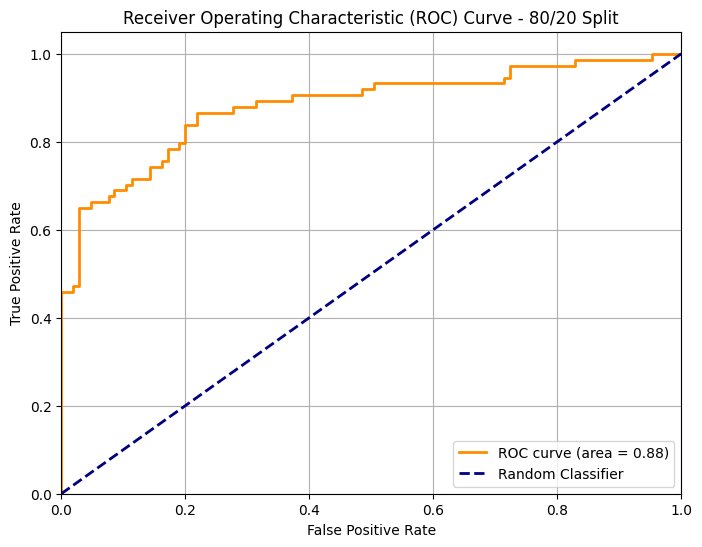

ROC curve plotted for the 80/20 split.


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve for the 80/20 split
fpr_80, tpr_80, thresholds_80 = roc_curve(y_test_80, y_prob_80)
roc_auc_80_plot = auc(fpr_80, tpr_80)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_80, tpr_80, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_80_plot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - 80/20 Split')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC curve plotted for the 80/20 split.")

Task 3;
1. Load dataset and preprocess categorical columns if present.
2. Train Logistic Regression with different train/test splits:
70/30, 80/20, 85/15
3. For each split calculate:
Accuracy
Precision, Recall, F1-score
4. Plot confusion matrix for each split.
5. Identify which split gives stable results


In [26]:
print("First 5 rows of X (Features):")
print(X.head())

print("\nFirst 5 rows of y (Target):")
print(y.head())

print("\nInfo of X DataFrame:")
X.info()

# Update the 'features' list to match the actual columns in X
features = X.columns.tolist()

print("\nUpdated selected features:")
print(features)

# Identify numerical columns within the features list for StandardScaler
numerical_cols = X[features].select_dtypes(include=['number', 'bool']).columns.tolist()
# Boolean columns are treated as numerical (0 or 1) by StandardScaler

print("\nNumerical columns identified for scaling:")
print(numerical_cols)

First 5 rows of X (Features):
     Pclass       Age     SibSp     Parch      Fare  Sex_male  Embarked_Q  \
0  0.827377 -0.565736  0.432793 -0.473674 -0.502445  0.737695   -0.307562   
1 -1.566107  0.663861  0.432793 -0.473674  0.786845 -1.355574   -0.307562   
2  0.827377 -0.258337 -0.474545 -0.473674 -0.488854 -1.355574   -0.307562   
3 -1.566107  0.433312  0.432793 -0.473674  0.420730 -1.355574   -0.307562   
4  0.827377  0.433312 -0.474545 -0.473674 -0.486337  0.737695   -0.307562   

   Embarked_S  
0    0.615838  
1   -1.623803  
2    0.615838  
3    0.615838  
4    0.615838  

First 5 rows of y (Target):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Info of X DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    float64
 1   Age         891 non-null    float64
 2   SibSp       891 non-nul

Data split into training (70%) and testing (30%) sets.
Training samples: 623, Test samples: 268

Logistic Regression model trained successfully for 70/30 split.

Evaluation Metrics for 70/30 Split:
Accuracy: 0.8097
Precision: 0.7941
Recall: 0.7297
F1-Score: 0.7606


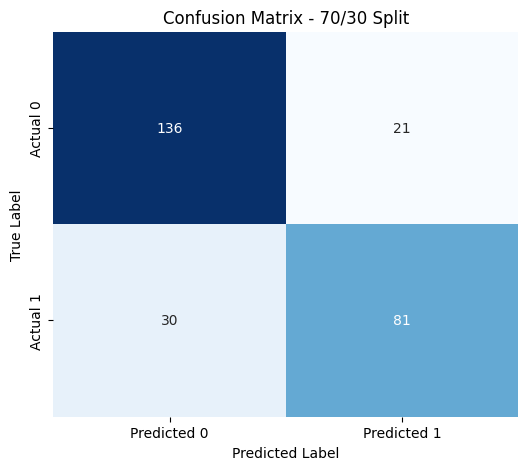

Confusion Matrix plotted for 70/30 split.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split the data into training and testing sets (70/30 split)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Data split into training (70%) and testing (30%) sets.\nTraining samples: {len(X_train_70)}, Test samples: {len(X_test_70)}\n")

# Instantiate and train the Logistic Regression model
model_70 = LogisticRegression(solver='liblinear', random_state=42)
model_70.fit(X_train_70, y_train_70)

print("Logistic Regression model trained successfully for 70/30 split.\n")

# Make predictions on the test data
y_pred_70 = model_70.predict(X_test_70)

# Calculate evaluation metrics
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
precision_70 = precision_score(y_test_70, y_pred_70)
recall_70 = recall_score(y_test_70, y_pred_70)
f1_70 = f1_score(y_test_70, y_pred_70)
conf_matrix_70 = confusion_matrix(y_test_70, y_pred_70)

print("Evaluation Metrics for 70/30 Split:")
print(f"Accuracy: {accuracy_70:.4f}")
print(f"Precision: {precision_70:.4f}")
print(f"Recall: {recall_70:.4f}")
print(f"F1-Score: {f1_70:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_70, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - 70/30 Split')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix plotted for 70/30 split.")

Data split into training (80%) and testing (20%) sets.
Training samples: 712, Test samples: 179

Logistic Regression model trained successfully for 80/20 split.

Evaluation Metrics for 80/20 Split:
Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1-Score: 0.7639


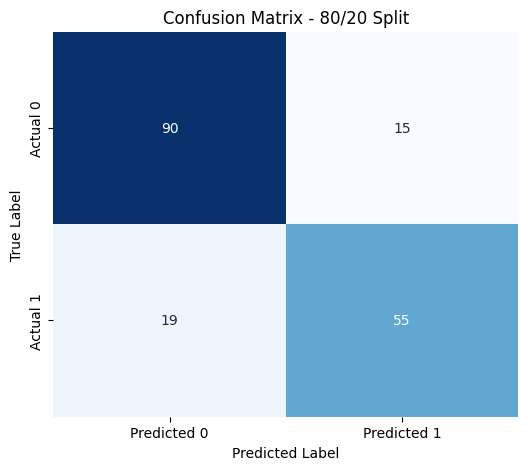

Confusion Matrix plotted for 80/20 split.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split the data into training and testing sets (80/20 split)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into training (80%) and testing (20%) sets.\nTraining samples: {len(X_train_80)}, Test samples: {len(X_test_80)}\n")

# Instantiate and train the Logistic Regression model
model_80 = LogisticRegression(solver='liblinear', random_state=42)
model_80.fit(X_train_80, y_train_80)

print("Logistic Regression model trained successfully for 80/20 split.\n")

# Make predictions on the test data
y_pred_80 = model_80.predict(X_test_80)

# Calculate evaluation metrics
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
precision_80 = precision_score(y_test_80, y_pred_80)
recall_80 = recall_score(y_test_80, y_pred_80)
f1_80 = f1_score(y_test_80, y_pred_80)
conf_matrix_80 = confusion_matrix(y_test_80, y_pred_80)

print("Evaluation Metrics for 80/20 Split:")
print(f"Accuracy: {accuracy_80:.4f}")
print(f"Precision: {precision_80:.4f}")
print(f"Recall: {recall_80:.4f}")
print(f"F1-Score: {f1_80:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_80, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - 80/20 Split')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix plotted for 80/20 split.")

Data split into training (85%) and testing (15%) sets.
Training samples: 757, Test samples: 134

Logistic Regression model trained successfully for 85/15 split.

Evaluation Metrics for 85/15 Split:
Accuracy: 0.8134
Precision: 0.7925
Recall: 0.7500
F1-Score: 0.7706


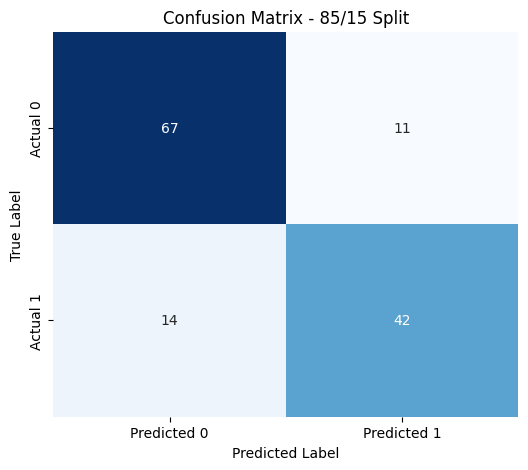

Confusion Matrix plotted for 85/15 split.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split the data into training and testing sets (85/15 split)
X_train_85, X_test_85, y_train_85, y_test_85 = train_test_split(X, y, test_size=0.15, random_state=42)

print(f"Data split into training (85%) and testing (15%) sets.\nTraining samples: {len(X_train_85)}, Test samples: {len(X_test_85)}\n")

# Instantiate and train the Logistic Regression model
model_85 = LogisticRegression(solver='liblinear', random_state=42)
model_85.fit(X_train_85, y_train_85)

print("Logistic Regression model trained successfully for 85/15 split.\n")

# Make predictions on the test data
y_pred_85 = model_85.predict(X_test_85)

# Calculate evaluation metrics
accuracy_85 = accuracy_score(y_test_85, y_pred_85)
precision_85 = precision_score(y_test_85, y_pred_85)
recall_85 = recall_score(y_test_85, y_pred_85)
f1_85 = f1_score(y_test_85, y_pred_85)
conf_matrix_85 = confusion_matrix(y_test_85, y_pred_85)

print("Evaluation Metrics for 85/15 Split:")
print(f"Accuracy: {accuracy_85:.4f}")
print(f"Precision: {precision_85:.4f}")
print(f"Recall: {recall_85:.4f}")
print(f"F1-Score: {f1_85:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_85, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - 85/15 Split')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix plotted for 85/15 split.")

In [29]:
import pandas as pd

results_task3 = {
    '70/30 Split': {
        'Accuracy': accuracy_70,
        'Precision': precision_70,
        'Recall': recall_70,
        'F1-Score': f1_70,
        'Confusion Matrix': conf_matrix_70.tolist()
    },
    '80/20 Split': {
        'Accuracy': accuracy_80,
        'Precision': precision_80,
        'Recall': recall_80,
        'F1-Score': f1_80,
        'Confusion Matrix': conf_matrix_80.tolist()
    },
    '85/15 Split': {
        'Accuracy': accuracy_85,
        'Precision': precision_85,
        'Recall': recall_85,
        'F1-Score': f1_85,
        'Confusion Matrix': conf_matrix_85.tolist()
    }
}

# Convert to DataFrame for better readability
results_df_task3 = pd.DataFrame(results_task3).T


print("\n--- Performance Comparison Across Different Train/Test Splits (Task 3) ---")
print(results_df_task3.to_markdown(numalign="left", stralign="left"))

print("\nNote: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]")


--- Performance Comparison Across Different Train/Test Splits (Task 3) ---
|             | Accuracy   | Precision   | Recall   | F1-Score   | Confusion Matrix      |
|:------------|:-----------|:------------|:---------|:-----------|:----------------------|
| 70/30 Split | 0.809701   | 0.794118    | 0.72973  | 0.760563   | [[136, 21], [30, 81]] |
| 80/20 Split | 0.810056   | 0.785714    | 0.743243 | 0.763889   | [[90, 15], [19, 55]]  |
| 85/15 Split | 0.813433   | 0.792453    | 0.75     | 0.770642   | [[67, 11], [14, 42]]  |

Note: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]


Task 4:
1. Load dataset and remove unnecessary columns (id, unnamed columns).
2. Encode target (diagnosis: M=1, B=0).
3. Train Logistic Regression with train/test splits:
50/50, 70/30, 80/20
4. Compare results using:
Accuracy
Confusion Matrix
ROC-AUC
5. Write a short inference on overfitting/underfitting based on split size.


In [30]:
import pandas as pd

# 1. Load the '/content/Titanic-Dataset.csv' file into a pandas DataFrame
df_task4 = pd.read_csv('/content/Titanic-Dataset.csv')

print('Original DataFrame shape:', df_task4.shape)

# 2. Drop the columns 'PassengerId', 'Name', and 'Ticket'
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
df_task4 = df_task4.drop(columns=columns_to_drop)

print('DataFrame shape after dropping columns:', df_task4.shape)

# 3. Display the first 5 rows of the modified df_task4 DataFrame
print('\nFirst 5 rows of the modified DataFrame:')
print(df_task4.head())

# 4. Display the information about the df_task4 DataFrame
print('\nInfo of the modified DataFrame:')
df_task4.info()

Original DataFrame shape: (891, 12)
DataFrame shape after dropping columns: (891, 9)

First 5 rows of the modified DataFrame:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S

Info of the modified DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    i

In [31]:
import pandas as pd

# Identify the target variable
target_variable_task4 = 'Survived'

# Separate features (X) and target (y)
df_task4_X = df_task4.drop(columns=[target_variable_task4, 'Cabin'])
# Dropping 'Cabin' as it has too many missing values and is not a core feature for this task.
df_task4_y = df_task4[target_variable_task4]

print(f"Target variable '{target_variable_task4}' is already numerical (0 and 1), no encoding needed.")

print('\nFirst 5 rows of features (df_task4_X):')
print(df_task4_X.head())

print('\nFirst 5 rows of target (df_task4_y):')
print(df_task4_y.head())

print('\nInfo of df_task4_X DataFrame (before further preprocessing):')
df_task4_X.info()

# Handle missing values in features
# Age: numerical, impute with median
df_task4_X['Age'] = df_task4_X['Age'].fillna(df_task4_X['Age'].median())

# Embarked: categorical, impute with mode
df_task4_X['Embarked'] = df_task4_X['Embarked'].fillna(df_task4_X['Embarked'].mode()[0])

print('\nMissing values in df_task4_X after imputation:')
print(df_task4_X.isnull().sum())

# One-hot encode categorical features ('Sex', 'Embarked')
categorical_cols_task4 = ['Sex', 'Embarked']
df_task4_X = pd.get_dummies(df_task4_X, columns=categorical_cols_task4, drop_first=True)

print('\nFirst 5 rows of features (df_task4_X) after encoding:')
print(df_task4_X.head())

print('\nInfo of df_task4_X DataFrame (after encoding):')
df_task4_X.info()


Target variable 'Survived' is already numerical (0 and 1), no encoding needed.

First 5 rows of features (df_task4_X):
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

First 5 rows of target (df_task4_y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Info of df_task4_X DataFrame (before further preprocessing):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5  

In [32]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns within df_task4_X for StandardScaler
# Boolean columns (from one-hot encoding) are treated as numerical (0 or 1) by StandardScaler.
# All columns in df_task4_X are now numerical or boolean, so all will be scaled.
numerical_cols_task4 = df_task4_X.columns.tolist()

print("df_task4_X DataFrame before scaling (first 5 rows):")
print(df_task4_X[numerical_cols_task4].head())

# Initialize the StandardScaler
scaler_task4 = StandardScaler()

# Apply StandardScaler to the numerical columns of df_task4_X
df_task4_X[numerical_cols_task4] = scaler_task4.fit_transform(df_task4_X[numerical_cols_task4])

print("\ndf_task4_X DataFrame after scaling (first 5 rows):")
print(df_task4_X[numerical_cols_task4].head())

print("\nFeature scaling applied to numerical columns successfully for Task 4.")

df_task4_X DataFrame before scaling (first 5 rows):
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

df_task4_X DataFrame after scaling (first 5 rows):
     Pclass       Age     SibSp     Parch      Fare  Sex_male  Embarked_Q  \
0  0.827377 -0.565736  0.432793 -0.473674 -0.502445  0.737695   -0.307562   
1 -1.566107  0.663861  0.432793 -0.473674  0.786845 -1.355574   -0.307562   
2  0.827377 -0.258337 -0.474545 -0.473674 -0.488854 -1.355574   -0.307562   
3 -1.566107  0.433312  0.432793 -0.473674  0.420730 -1.355574   -0.307562   
4  0.827377  0.433312 -0.474545 -0.473674 -0.486337  0.737695   -0.307562

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Split the data into training and testing sets (50/50 split)
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(df_task4_X, df_task4_y, test_size=0.5, random_state=42)

print(f"Data split into training (50%) and testing (50%) sets.\nTraining samples: {len(X_train_50)}, Test samples: {len(X_test_50)}\n")

# Instantiate and train the Logistic Regression model
model_50 = LogisticRegression(solver='liblinear', random_state=42)
model_50.fit(X_train_50, y_train_50)

print("Logistic Regression model trained successfully for 50/50 split.\n")

# Make predictions on the test data
y_pred_50 = model_50.predict(X_test_50)

# Get probability predictions for ROC-AUC
y_prob_50 = model_50.predict_proba(X_test_50)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_50 = accuracy_score(y_test_50, y_pred_50)
conf_matrix_50 = confusion_matrix(y_test_50, y_pred_50)
roc_auc_50 = roc_auc_score(y_test_50, y_prob_50)

print("Evaluation Metrics for 50/50 Split:")
print(f"Accuracy: {accuracy_50:.4f}")
print("Confusion Matrix:")
print(conf_matrix_50)
print(f"ROC-AUC Score: {roc_auc_50:.4f}")

Data split into training (50%) and testing (50%) sets.
Training samples: 445, Test samples: 446

Logistic Regression model trained successfully for 50/50 split.

Evaluation Metrics for 50/50 Split:
Accuracy: 0.8072
Confusion Matrix:
[[233  34]
 [ 52 127]]
ROC-AUC Score: 0.8554


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Split the data into training and testing sets (70/30 split)
X_train_70_task4, X_test_70_task4, y_train_70_task4, y_test_70_task4 = train_test_split(df_task4_X, df_task4_y, test_size=0.3, random_state=42)

print(f"Data split into training (70%) and testing (30%) sets.\nTraining samples: {len(X_train_70_task4)}, Test samples: {len(X_test_70_task4)}\n")

# Instantiate and train the Logistic Regression model
model_70_task4 = LogisticRegression(solver='liblinear', random_state=42)
model_70_task4.fit(X_train_70_task4, y_train_70_task4)

print("Logistic Regression model trained successfully for 70/30 split.\n")

# Make predictions on the test data
y_pred_70_task4 = model_70_task4.predict(X_test_70_task4)

# Get probability predictions for ROC-AUC
y_prob_70_task4 = model_70_task4.predict_proba(X_test_70_task4)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_70_task4 = accuracy_score(y_test_70_task4, y_pred_70_task4)
conf_matrix_70_task4 = confusion_matrix(y_test_70_task4, y_pred_70_task4)
roc_auc_70_task4 = roc_auc_score(y_test_70_task4, y_prob_70_task4)

print("Evaluation Metrics for 70/30 Split:")
print(f"Accuracy: {accuracy_70_task4:.4f}")
print("Confusion Matrix:")
print(conf_matrix_70_task4)
print(f"ROC-AUC Score: {roc_auc_70_task4:.4f}")

Data split into training (70%) and testing (30%) sets.
Training samples: 623, Test samples: 268

Logistic Regression model trained successfully for 70/30 split.

Evaluation Metrics for 70/30 Split:
Accuracy: 0.8097
Confusion Matrix:
[[136  21]
 [ 30  81]]
ROC-AUC Score: 0.8797


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Split the data into training and testing sets (80/20 split)
X_train_80_task4, X_test_80_task4, y_train_80_task4, y_test_80_task4 = train_test_split(df_task4_X, df_task4_y, test_size=0.2, random_state=42)

print(f"Data split into training (80%) and testing (20%) sets.\nTraining samples: {len(X_train_80_task4)}, Test samples: {len(X_test_80_task4)}\n")

# Instantiate and train the Logistic Regression model
model_80_task4 = LogisticRegression(solver='liblinear', random_state=42)
model_80_task4.fit(X_train_80_task4, y_train_80_task4)

print("Logistic Regression model trained successfully for 80/20 split.\n")

# Make predictions on the test data
y_pred_80_task4 = model_80_task4.predict(X_test_80_task4)

# Get probability predictions for ROC-AUC
y_prob_80_task4 = model_80_task4.predict_proba(X_test_80_task4)[:, 1] # Probability of the positive class

# Calculate and print evaluation metrics
accuracy_80_task4 = accuracy_score(y_test_80_task4, y_pred_80_task4)
conf_matrix_80_task4 = confusion_matrix(y_test_80_task4, y_pred_80_task4)
roc_auc_80_task4 = roc_auc_score(y_test_80_task4, y_prob_80_task4)

print("Evaluation Metrics for 80/20 Split:")
print(f"Accuracy: {accuracy_80_task4:.4f}")
print("Confusion Matrix:")
print(conf_matrix_80_task4)
print(f"ROC-AUC Score: {roc_auc_80_task4:.4f}")

Data split into training (80%) and testing (20%) sets.
Training samples: 712, Test samples: 179

Logistic Regression model trained successfully for 80/20 split.

Evaluation Metrics for 80/20 Split:
Accuracy: 0.8101
Confusion Matrix:
[[90 15]
 [19 55]]
ROC-AUC Score: 0.8820


In [36]:
import pandas as pd

results_task4 = {
    '50/50 Split': {
        'Accuracy': accuracy_50,
        'ROC-AUC Score': roc_auc_50,
        'Confusion Matrix': conf_matrix_50.tolist()
    },
    '70/30 Split': {
        'Accuracy': accuracy_70_task4,
        'ROC-AUC Score': roc_auc_70_task4,
        'Confusion Matrix': conf_matrix_70_task4.tolist()
    },
    '80/20 Split': {
        'Accuracy': accuracy_80_task4,
        'ROC-AUC Score': roc_auc_80_task4,
        'Confusion Matrix': conf_matrix_80_task4.tolist()
    }
}

# Convert to DataFrame for better readability
results_df_task4 = pd.DataFrame(results_task4).T

print("\n--- Performance Comparison Across Different Train/Test Splits (Task 4) ---")
print(results_df_task4.to_markdown(numalign="left", stralign="left"))

print("\nNote: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]")


--- Performance Comparison Across Different Train/Test Splits (Task 4) ---
|             | Accuracy   | ROC-AUC Score   | Confusion Matrix       |
|:------------|:-----------|:----------------|:-----------------------|
| 50/50 Split | 0.807175   | 0.855439        | [[233, 34], [52, 127]] |
| 70/30 Split | 0.809701   | 0.879727        | [[136, 21], [30, 81]]  |
| 80/20 Split | 0.810056   | 0.881982        | [[90, 15], [19, 55]]   |

Note: Confusion Matrix is displayed as [[True Negative, False Positive], [False Negative, True Positive]]


Tasks 5:
1. Load dataset and use features:Age, Estimated Salary
Target: Purchased
2. Apply StandardScaler and train Logistic Regression model.
3. Test the model using train/test splits:
65/35, 75/25, 80/20
4. Report:
Accuracy
Confusion Matrix
Classification Report
5. Plot decision boundary (2D) for the best split

In [37]:
import pandas as pd

# Load the dataset from the file path '/content/Social_Network_Ads.csv'
df_task5 = pd.read_csv('/content/Social_Network_Ads.csv')

# Create a new DataFrame X_task5 by selecting the 'Age' and 'Estimated Salary' columns
X_task5 = df_task5[['Age', 'EstimatedSalary']]

# Create a new Series y_task5 by selecting the 'Purchased' column
y_task5 = df_task5['Purchased']

print('First 5 rows of the original DataFrame (df_task5):')
print(df_task5.head())

print('\nInformation about the original DataFrame (df_task5):')
df_task5.info()

print('\nFirst 5 rows of features (X_task5):')
print(X_task5.head())

print('\nFirst 5 rows of target (y_task5):')
print(y_task5.head())

First 5 rows of the original DataFrame (df_task5):
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Information about the original DataFrame (df_task5):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

First 5 rows of features (X_task5):
   Age  EstimatedSalary
0   19            19000
1   35            2000

In [38]:
from sklearn.preprocessing import StandardScaler

print("Features (X_task5) before scaling (first 5 rows):")
print(X_task5.head())

# Initialize the StandardScaler
scaler_task5 = StandardScaler()

# Apply StandardScaler to the features
X_task5_scaled = scaler_task5.fit_transform(X_task5)

# Convert the scaled features back to a DataFrame for consistency
X_task5 = pd.DataFrame(X_task5_scaled, columns=X_task5.columns)

print("\nFeatures (X_task5) after scaling (first 5 rows):")
print(X_task5.head())

print("\nFeature scaling applied successfully to X_task5.")

Features (X_task5) before scaling (first 5 rows):
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Features (X_task5) after scaling (first 5 rows):
        Age  EstimatedSalary
0 -1.781797        -1.490046
1 -0.253587        -1.460681
2 -1.113206        -0.785290
3 -1.017692        -0.374182
4 -1.781797         0.183751

Feature scaling applied successfully to X_task5.


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split the data into training and testing sets (65/35 split)
X_train_65, X_test_65, y_train_65, y_test_65 = train_test_split(X_task5, y_task5, test_size=0.35, random_state=42)

print(f"Data split into training (65%) and testing (35%) sets.\nTraining samples: {len(X_train_65)}, Test samples: {len(X_test_65)}\n")

# Instantiate and train the Logistic Regression model
model_65 = LogisticRegression(solver='liblinear', random_state=42)
model_65.fit(X_train_65, y_train_65)

print("Logistic Regression model trained successfully for 65/35 split.\n")

# Make predictions on the test data
y_pred_65 = model_65.predict(X_test_65)

# Calculate and print evaluation metrics
accuracy_65 = accuracy_score(y_test_65, y_pred_65)
conf_matrix_65 = confusion_matrix(y_test_65, y_pred_65)
class_report_65 = classification_report(y_test_65, y_pred_65)

print("Evaluation Metrics for 65/35 Split:")
print(f"Accuracy: {accuracy_65:.4f}")
print("Confusion Matrix:")
print(conf_matrix_65)
print("Classification Report:\n", class_report_65)

Data split into training (65%) and testing (35%) sets.
Training samples: 260, Test samples: 140

Logistic Regression model trained successfully for 65/35 split.

Evaluation Metrics for 65/35 Split:
Accuracy: 0.8357
Confusion Matrix:
[[81  3]
 [20 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.96      0.88        84
           1       0.92      0.64      0.76        56

    accuracy                           0.84       140
   macro avg       0.86      0.80      0.82       140
weighted avg       0.85      0.84      0.83       140



In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split the data into training and testing sets (75/25 split)
X_train_75, X_test_75, y_train_75, y_test_75 = train_test_split(X_task5, y_task5, test_size=0.25, random_state=42)

print(f"Data split into training (75%) and testing (25%) sets.\nTraining samples: {len(X_train_75)}, Test samples: {len(X_test_75)}\n")

# Instantiate and train the Logistic Regression model
model_75 = LogisticRegression(solver='liblinear', random_state=42)
model_75.fit(X_train_75, y_train_75)

print("Logistic Regression model trained successfully for 75/25 split.\n")

# Make predictions on the test data
y_pred_75 = model_75.predict(X_test_75)

# Calculate and print evaluation metrics
accuracy_75 = accuracy_score(y_test_75, y_pred_75)
conf_matrix_75 = confusion_matrix(y_test_75, y_pred_75)
class_report_75 = classification_report(y_test_75, y_pred_75)

print("Evaluation Metrics for 75/25 Split:")
print(f"Accuracy: {accuracy_75:.4f}")
print("Confusion Matrix:")
print(conf_matrix_75)
print("Classification Report:\n", class_report_75)

Data split into training (75%) and testing (25%) sets.
Training samples: 300, Test samples: 100

Logistic Regression model trained successfully for 75/25 split.

Evaluation Metrics for 75/25 Split:
Accuracy: 0.8800
Confusion Matrix:
[[61  2]
 [10 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100



In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split the data into training and testing sets (80/20 split)
X_train_80_task5, X_test_80_task5, y_train_80_task5, y_test_80_task5 = train_test_split(X_task5, y_task5, test_size=0.20, random_state=42)

print(f"Data split into training (80%) and testing (20%) sets.\nTraining samples: {len(X_train_80_task5)}, Test samples: {len(X_test_80_task5)}\n")

# Instantiate and train the Logistic Regression model
model_80_task5 = LogisticRegression(solver='liblinear', random_state=42)
model_80_task5.fit(X_train_80_task5, y_train_80_task5)

print("Logistic Regression model trained successfully for 80/20 split.\n")

# Make predictions on the test data
y_pred_80_task5 = model_80_task5.predict(X_test_80_task5)

# Calculate and print evaluation metrics
accuracy_80_task5 = accuracy_score(y_test_80_task5, y_pred_80_task5)
conf_matrix_80_task5 = confusion_matrix(y_test_80_task5, y_pred_80_task5)
class_report_80_task5 = classification_report(y_test_80_task5, y_pred_80_task5)

print("Evaluation Metrics for 80/20 Split:")
print(f"Accuracy: {accuracy_80_task5:.4f}")
print("Confusion Matrix:")
print(conf_matrix_80_task5)
print("Classification Report:\n", class_report_80_task5)

Data split into training (80%) and testing (20%) sets.
Training samples: 320, Test samples: 80

Logistic Regression model trained successfully for 80/20 split.

Evaluation Metrics for 80/20 Split:
Accuracy: 0.8750
Confusion Matrix:
[[50  2]
 [ 8 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91        52
           1       0.91      0.71      0.80        28

    accuracy                           0.88        80
   macro avg       0.89      0.84      0.85        80
weighted avg       0.88      0.88      0.87        80



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


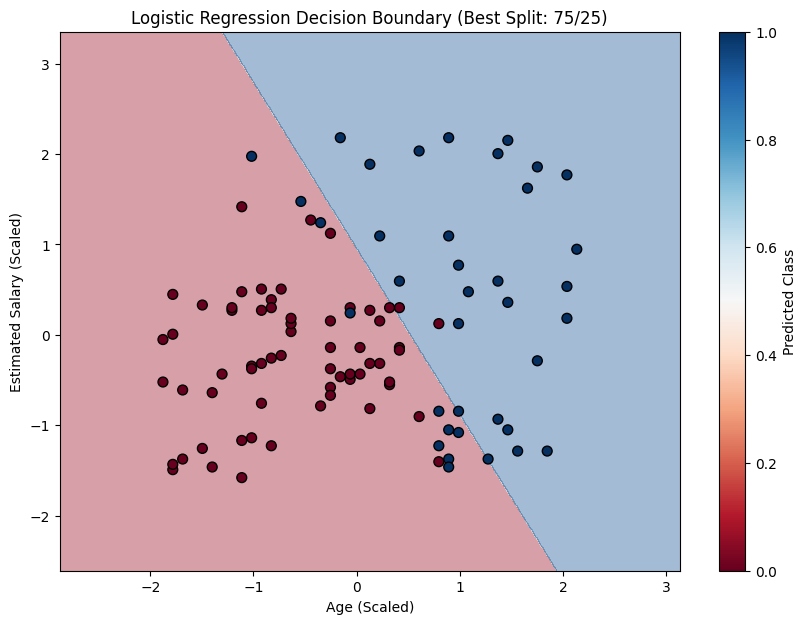

Decision boundary plotted for the best performing split (75/25).


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming model_75, X_test_75, y_test_75, X_task5 (scaled) are available from previous steps

# Identify the best model (based on the highest accuracy among the three splits)
# From the previous outputs:
# 65/35 split Accuracy: 0.8357
# 75/25 split Accuracy: 0.8800
# 80/20 split Accuracy: 0.8750

# The 75/25 split has the highest accuracy, so we'll use model_75
best_model = model_75
X_plot = X_test_75
y_plot = y_test_75

# Get min and max values for Age and EstimatedSalary (original column names from X_task5)
# X_task5 contains the scaled values
# We need to use the original X_task5 (scaled) to determine the plot limits for the scaled data
# or inverse transform if we want to plot with original scale, but generally scaled is used for decision boundary.

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_task5.iloc[:, 0].min() - 1, X_task5.iloc[:, 0].max() + 1
y_min, y_max = X_task5.iloc[:, 1].min() - 1, X_task5.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict class for each point in the meshgrid
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

# Plot the test data points
plt.scatter(X_plot.iloc[:, 0], X_plot.iloc[:, 1], c=y_plot, s=50, edgecolors='k', cmap=plt.cm.RdBu)

plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.title('Logistic Regression Decision Boundary (Best Split: 75/25)')
plt.colorbar(label='Predicted Class')
plt.show()

print("Decision boundary plotted for the best performing split (75/25).")

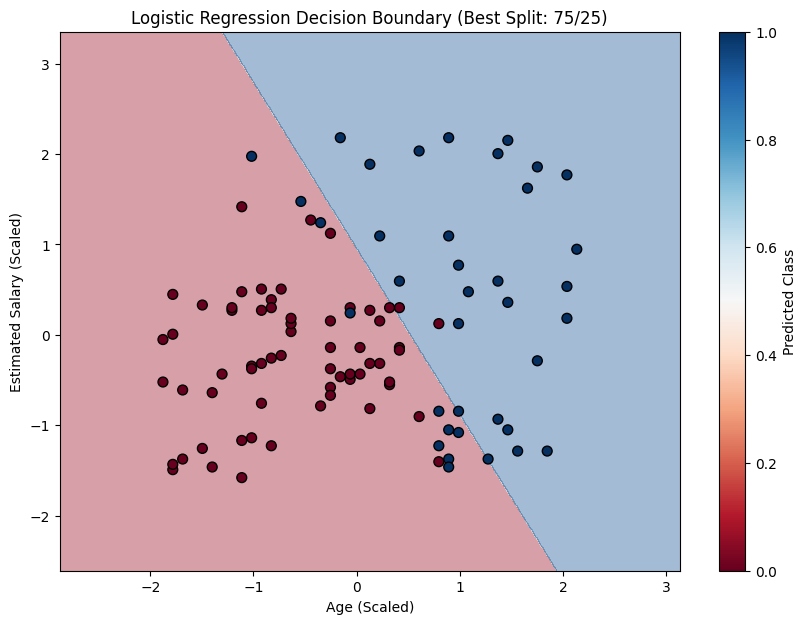

Decision boundary plotted for the best performing split (75/25).


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming model_75, X_test_75, y_test_75, X_task5 (scaled) are available from previous steps

# Identify the best model (based on the highest accuracy among the three splits)
# From the previous outputs:
# 65/35 split Accuracy: 0.8357
# 75/25 split Accuracy: 0.8800
# 80/20 split Accuracy: 0.8750

# The 75/25 split has the highest accuracy, so we'll use model_75
best_model = model_75
X_plot = X_test_75
y_plot = y_test_75

# Get min and max values for Age and EstimatedSalary (original column names from X_task5)
# X_task5 contains the scaled values
# We need to use the original X_task5 (scaled) to determine the plot limits for the scaled data
# or inverse transform if we want to plot with original scale, but generally scaled is used for decision boundary.

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_task5.iloc[:, 0].min() - 1, X_task5.iloc[:, 0].max() + 1
y_min, y_max = X_task5.iloc[:, 1].min() - 1, X_task5.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predict class for each point in the meshgrid
# Create a DataFrame from the meshgrid points with original column names
meshgrid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_task5.columns)
Z = best_model.predict(meshgrid_df)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

# Plot the test data points
plt.scatter(X_plot.iloc[:, 0], X_plot.iloc[:, 1], c=y_plot, s=50, edgecolors='k', cmap=plt.cm.RdBu)

plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.title('Logistic Regression Decision Boundary (Best Split: 75/25)')
plt.colorbar(label='Predicted Class')
plt.show()

print("Decision boundary plotted for the best performing split (75/25).")